In [1]:
#Aim at improving ml skills
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import kagglehub
from pathlib import Path
# Download latest version
path = kagglehub.dataset_download("arifmia/agricultural-land-suitability-and-soil-quality")

print("Path to dataset files:", path)

100%|██████████| 26.9k/26.9k [00:00<00:00, 39.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/arifmia/agricultural-land-suitability-and-soil-quality/versions/1


In [5]:
path = path / Path("bangladesh_divisions_dataset.csv")
print(path)

/root/.cache/kagglehub/datasets/arifmia/agricultural-land-suitability-and-soil-quality/versions/1/bangladesh_divisions_dataset.csv


In [6]:
df = pd.read_csv(path)

df.tail()

,Location,Soil_Type,Fertility_Index,Land_Use_Type,Average_Rainfall(mm),Temperature(°C),Crop_Suitability,Season,Satellite_Observation_Date,Remarks
1995,Barishal,Loamy,65,Unused,278,20.3,Spices,Summer,2024-02-12,Requires attention
1996,Chattogram,Clay,52,Residential,224,29.3,Jute,Winter,2024-08-20,Moderate potential
1997,Rangpur,Clay,97,Barren,84,25.6,Jute,Summer,2024-09-07,Requires attention
1998,Rajshahi,Sandy,85,Residential,209,23.5,Rice,Summer,2024-08-23,Moderate potential
1999,Sylhet,Sandy,73,Agricultural,134,20.2,Wheat,Winter,2024-11-01,Moderate potential


In [7]:
df["Location"].unique()

array(['Sylhet', 'Dhaka', 'Rangpur', 'Khulna', 'Rajshahi', 'Chattogram',
       'Barishal', 'Mymensingh'], dtype=object)

In [8]:
df["Location"].nunique()

8

<BarContainer object of 2000 artists>

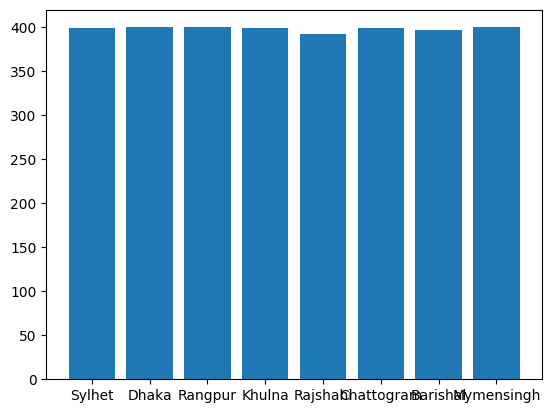

In [9]:
plt.bar(data=df , x = "Location" , height = "Average_Rainfall(mm)")

In [10]:
df["Average_Rainfall(mm)"].max()

400

In [11]:
px.bar(data_frame=df , x ="Location" , y = "Average_Rainfall(mm)")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Location                    2000 non-null   object 
 1   Soil_Type                   2000 non-null   object 
 2   Fertility_Index             2000 non-null   int64  
 3   Land_Use_Type               2000 non-null   object 
 4   Average_Rainfall(mm)        2000 non-null   int64  
 5   Temperature(°C)             2000 non-null   float64
 6   Crop_Suitability            2000 non-null   object 
 7   Season                      2000 non-null   object 
 8   Satellite_Observation_Date  2000 non-null   object 
 9   Remarks                     2000 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 156.4+ KB


([<matplotlib.axis.YTick at 0x7e8a6238dbd0>,
 [Text(0, 40, '40'),
  Text(0, 50, '50'),
  Text(0, 60, '60'),
  Text(0, 70, '70'),
  Text(0, 80, '80'),
  Text(0, 90, '90')])

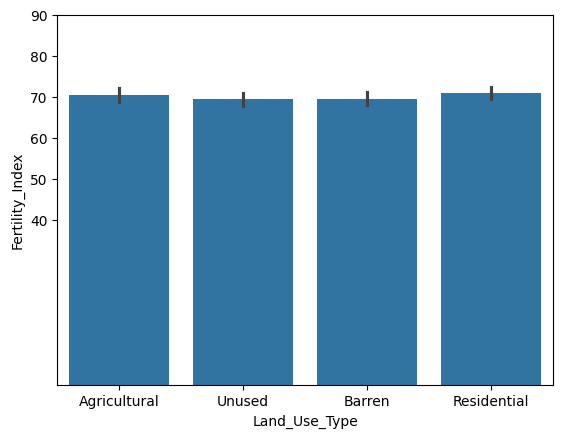

In [26]:
sns.barplot(data=df , x = "Land_Use_Type" , y = "Fertility_Index")
plt.yticks(range(40,100,10))

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Location                    2000 non-null   object 
 1   Soil_Type                   2000 non-null   object 
 2   Fertility_Index             2000 non-null   int64  
 3   Land_Use_Type               2000 non-null   object 
 4   Average_Rainfall(mm)        2000 non-null   int64  
 5   Temperature(°C)             2000 non-null   float64
 6   Crop_Suitability            2000 non-null   object 
 7   Season                      2000 non-null   object 
 8   Satellite_Observation_Date  2000 non-null   object 
 9   Remarks                     2000 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 156.4+ KB


In [35]:
#!pip install plotly.express

import plotly.express as px
import pandas as pd

# Assuming 'df' contains a 'Location' column with geographic names
fig = px.choropleth(
    df,
    geojson="https://raw.githubusercontent.com/deldersveld/topojson/master/countries/bangladesh/bangladesh-divisions.json", # Replace with appropriate GeoJSON for Bangladesh divisions
    locations='Location',
    featureidkey="properties.name",  # Adjust based on your GeoJSON structure
    color='Average_Rainfall(mm)',  # Replace with the column you want to visualize
    color_continuous_scale="Viridis",
)
fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()